<a href="https://colab.research.google.com/github/DaoNguyenMinhThy/Machine_Learning/blob/main/HM%26UD_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## `01. Linear_Regression`


# 3. Làm quen bộ dữ liệu

In [ ]:
#3.3. Đọc dữ liệu bằng pandas
import numpy, pandas, matplotlib, sklearn
import pandas as pd
"""Bước 1: đọc tệp dữ liệu và nhìn qua một lượt.
Chú thích trong tệp viết tiếng Việt có dấu, nhưng phần in ra màn hình cố ý
viết không dấu. Cửa sổ lệnh Windows thường không hiện được chữ có dấu."""

# Đọc tệp CSV thành một bảng. Tên df là viết tắt quen dùng của data frame.
df = pd.read_csv("gia_nha.csv")
print("Kich thuoc bang (so dong, so cot):", df.shape)
print()
print("Nam dong dau tien:")
print(df.head())
print()
print("Ten cac cot:", list(df.columns))
print()
print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()
print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


In [ ]:
#4.5. Tính thử bằng tay trên năm căn nhà
# -*- coding: utf-8 -*-
"""Bước 2: đo xem một đường thẳng dự đoán sai bao nhiêu.
Chỉ lấy 5 căn cho dễ nhìn. Thử hai đường thẳng khác nhau rồi so sai số
trung bình bình phương của từng đường."""

import pandas as pd

df = pd.read_csv("gia_nha.csv")

# Lấy 5 căn trải đều từ nhỏ nhất tới lớn nhất, không lấy 5 căn đầu bảng
# vì chúng có diện tích gần bằng nhau nên nhìn không rõ.
nho = df.iloc[[0, 14, 29, 44, 59]]
x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()

def mse(w, b):
    """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
    y_du_doan = w * x + b
    sai_so = y - y_du_doan
    return (sai_so ** 2).mean()

print("Nam can duoc chon:")
for i in range(5):
    print(f" {x[i]:6.1f} m2 -> {y[i]:5.2f} ty")
print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
    print(f"Duong thang y = {w} * x + {b}")
    for i in range(5):
        du_doan = w * x[i] + b
        sai_so = y[i] - du_doan
        print(f"  x = {x[i]:6.1f} that = {y[i]:5.2f}"
              f" du doan = {du_doan:5.2f} sai so = {sai_so:+6.2f}")
    print(f"  MSE = {mse(w, b):.4f}")
    print()

print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon.")

Nam can duoc chon:
   35.5 m2 ->  3.00 ty
   61.3 m2 ->  4.56 ty
   74.2 m2 ->  7.17 ty
   91.3 m2 ->  7.83 ty
  115.9 m2 ->  9.01 ty

Duong thang y = 0.05 * x + 1.5
  x =   35.5 that =  3.00 du doan =  3.28 sai so =  -0.28
  x =   61.3 that =  4.56 du doan =  4.56 sai so =  -0.00
  x =   74.2 that =  7.17 du doan =  5.21 sai so =  +1.96
  x =   91.3 that =  7.83 du doan =  6.07 sai so =  +1.76
  x =  115.9 that =  9.01 du doan =  7.30 sai so =  +1.71
  MSE = 1.9947

Duong thang y = 0.08 * x + 0.5
  x =   35.5 that =  3.00 du doan =  3.34 sai so =  -0.34
  x =   61.3 that =  4.56 du doan =  5.40 sai so =  -0.84
  x =   74.2 that =  7.17 du doan =  6.44 sai so =  +0.73
  x =   91.3 that =  7.83 du doan =  7.80 sai so =  +0.03
  x =  115.9 that =  9.01 du doan =  9.77 sai so =  -0.76
  MSE = 0.3896

Duong nao co MSE nho hon thi duong do khop du lieu tot hon.


# 5. Tìm đường thẳng tốt nhất

In [ ]:
#5.1. Cách 1: dùng công thức có sẵn
# -*- coding: utf-8 -*-
"""Bước 3: tìm w và b tốt nhất bằng công thức, không cần thư viện."""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu cho đường thẳng một biến
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()
w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung binh dien tich : {x_tb:.4f}")
print(f"Trung binh gia       : {y_tb:.4f}")
print(f"Tu so                : {tu_so:.4f}")
print(f"Mau so               : {mau_so:.4f}")
print()
print(f"He so goc  w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:.4f}")
print()

# Dự đoán cho một căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich : 77.7317
Trung binh gia       : 6.4933
Tu so                : 1890.2297
Mau so               : 24120.2898

He so goc  w = 0.078367
He so chan b = 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018
MSE tren toan bo 60 can: 0.1790

Can 80 m2 duoc du doan: 6.671 ty dong


In [ ]:
#5.2. Cách 2: để scikit‐learn làm
# -*- coding: utf-8 -*-
"""Bước 4: làm lại đúng việc đó bằng scikit-learn, chỉ mất ba dòng."""

import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("gia_nha.csv")

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)

for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")

He so goc w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 -> du doan 6.671 ty dong
Can 100 m2 -> du doan 8.238 ty dong


# 6. Đánh giá mô hình

In [8]:
#6.4. Chấm điểm mô hình của chúng ta
# -*- coding: utf-8 -*-
"""Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
X = df[["dien_tich"]]
y = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra.
# random_state cố định để lần nào chia cũng ra đúng một cách chia.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("So can de hoc     :", len(X_train))
print("So can de kiem tra:", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)  # chỉ học trên tập học
y_pred = mo_hinh.predict(X_test)  # chấm điểm trên tập kiểm tra

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f} ty dong")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2   = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    print(f" {dt:6.1f} m2 that = {that:5.2f} du doan = {du_doan:5.2f} sai so = {that - du_doan:+5.2f}")

So can de hoc     : 48
So can de kiem tra: 12

MAE  = 0.2578 ty dong
MSE  = 0.1392
RMSE = 0.3730 ty dong
R2   = 0.9622

Mot vai can trong tap kiem tra:
   35.5 m2 that =  3.00 du doan =  3.22 sai so = -0.22
   50.4 m2 that =  4.24 du doan =  4.38 sai so = -0.14
   82.5 m2 that =  7.28 du doan =  6.88 sai so = +0.40
   93.6 m2 that =  7.63 du doan =  7.74 sai so = -0.11
   59.6 m2 that =  5.14 du doan =  5.09 sai so = +0.05


In [9]:
#7.5. Chạy thử và đối chiếu với đáp án
# -*- coding: utf-8 -*-
"""Bước 6: tự đi tìm w và b bằng cách dò từng bước nhỏ.
Đây là cách máy học khi bài toán không có công thức đóng. Với hồi quy tuyến
tính ta đã có công thức rồi, nên đoạn này chỉ để thấy cơ chế hoạt động.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0  # bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1  # mỗi vòng lặp đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x)

print("Vong       w       b      MSE")
for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        # Tính lại MSE bằng w và b VỪA cập nhật, để ba con số trên cùng một
        # dòng bảng đều thuộc về cùng một thời điểm. Nếu dùng lại chenh_lech
        # ở trên thì MSE sẽ là của cặp w, b cũ và bảng bị lệch một vòng.
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d} {w:7.4f} {b:7.4f} {mse:8.4f}")

print()
# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech

print("Sau khi doi ve thang do met vuong:")
print(f"  w = {w_goc:.6f}")
print(f"  b = {b_goc:.6f}")
print()
print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")

Vong       w       b      MSE
   1  0.3143  1.2987  28.7437
   2  0.5657  2.3376  18.4604
   5  1.0564  4.3656   4.9714
  10  1.4025  5.7961   0.6936
  25  1.5653  6.4688   0.1797
  50  1.5712  6.4932   0.1790
 100  1.5713  6.4933   0.1790
 200  1.5713  6.4933   0.1790

Sau khi doi ve thang do met vuong:
  w = 0.078367
  b = 0.401752

So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752


# 8. Dùng nhiều hơn một biến

In [10]:
#8.2. Trong mã chỉ đổi đúng một chỗ
# -*- coding: utf-8 -*-
"""Bước 7: dùng thêm số phòng và tuổi nhà, xem mô hình có khá hơn không."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
y = df["gia"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien ", X_mot), ("Ba bien ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()

# Xem kỹ các hệ số của mô hình ba biến
X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh.intercept_:+.4f}")

Mot bien : R2 tren tap kiem tra = 0.9622
Ba bien : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
  dien_tich    +0.0701
  so_phong     +0.3042
  tuoi_nha     -0.0295
  he so chan   +0.6917


# 9. Bài tập

In [11]:
#Bài tập 1: Lọc ra nhóm căn hộ lớn
# -*- coding: utf-8 -*-
"""Bài tập 1: Lọc ra nhóm căn hộ lớn có diện tích > 100 m2."""

import pandas as pd

df = pd.read_csv("gia_nha.csv")

# Lọc ra nhóm căn hộ có diện tích lớn hơn 100 mét vuông
nhom_lon = df[df["dien_tich"] > 100]

# Con số thứ nhất: Số lượng căn hộ lớn hơn 100 m2
so_can = len(nhom_lon)

# Con số thứ hai: Giá trung bình của nhóm này (tính bằng tỷ đồng)
gia_trung_binh = nhom_lon["gia"].mean()

print(f"So can co dien tich lon hon 100 m2: {so_can}")
print(f"Gia trung binh cua nhom can nay    : {gia_trung_binh:.2f} ty dong")

So can co dien tich lon hon 100 m2: 10
Gia trung binh cua nhom can nay    : 8.96 ty dong


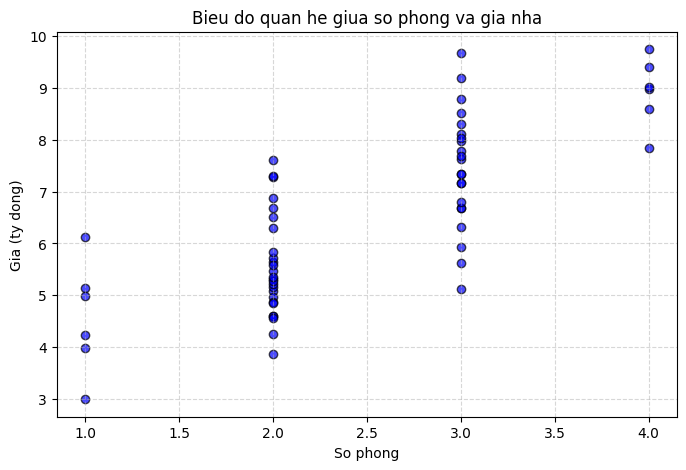

Nhan xet:
So phong co xu huong ty le thuan voi gia nha (can ho cang nhieu phong thi gia ban trung binh cang cao).


In [12]:
#Bài tập 2: Vẽ biểu đồ phân tán theo số phòng
# -*- coding: utf-8 -*-
"""Bài tập 2: Vẽ biểu đồ phân tán giữa số phòng và giá nhà."""

import matplotlib.pyplot as plt
import pandas as pd

# Đọc bộ dữ liệu
df = pd.read_csv("gia_nha.csv")

# Vẽ biểu đồ phân tán (scatter plot)
plt.figure(figsize=(8, 5))
plt.scatter(df["so_phong"], df["gia"], color="blue", alpha=0.7, edgecolors="k")

# Đặt tiêu đề và nhãn cho hai trục
plt.title("Bieu do quan he giua so phong va gia nha")
plt.xlabel("So phong")
plt.ylabel("Gia (ty dong)")
plt.grid(True, linestyle="--", alpha=0.5)

# Lưu hình ra tệp bai2.png trước khi gọi plt.show()
plt.savefig("bai2.png", dpi=150, bbox_inches="tight")

# Hiển thị biểu đồ
plt.show()

# Nhận xét xu hướng
print("Nhan xet:")
print("So phong co xu huong ty le thuan voi gia nha (can ho cang nhieu phong thi gia ban trung binh cang cao).")

In [13]:
#Bài tập 3: Đổi biến đầu vào sang tuổi nhà
# -*- coding: utf-8 -*-
"""Bài tập 3: Hồi quy tuyến tính bằng công thức đóng với biến tuoi_nha."""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")

# Đổi biến đầu vào từ dien_tich sang tuoi_nha
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

# Áp dụng công thức bình phương tối thiểu
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()
w = tu_so / mau_so
b = y_tb - w * x_tb

# In hệ số với 6 chữ số thập phân
print(f"He so goc  w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"Mo hinh: gia = ({w:.6f}) * tuoi_nha + {b:.6f}")
print()

# Giải thích bằng lời
print("Giai thich dau cua w")
print("1. Nhan xet: He so goc w mang dau am.")
print("2. Y nghia thuc te: w dai dien cho muc thay doi cua gia nha khi tuoi nha tang them 1 nam.")
print("   He so mang dau am the hien moi quan he nghich bien: nha cang cu (xay cang lau nam,")
print("   khau hao, xuong cap) thi gia tri ban lai cang giam.")
print()

print("Tra loi cau hoi them")
print("- Khi ve bieu do phan tan giua tuoi_nha va gia, cac diem du lieu phan tan kha roi rac,")
print("  khong he bam sat quanh mot duong thang dep nhu bieu do dien_tich.")
print("- Do do, mac du dau am cua w phan anh dung quy luat thuc te, muc do giai thich (do tin cay) cua")
print("  rieng bien tuoi_nha len gia nha la kha thap (R2 thap). Chi dau cua he so dung la chua du de")
print("  ket luan hai dai luong co quan he tuyen tinh chat che; can xem xet them do phan tan va cac chi so nhu R2.")

He so goc  w = -0.037858
He so chan b = 6.983593

Mo hinh: gia = (-0.037858) * tuoi_nha + 6.983593

--- Giai thich dau cua w ---
1. Nhan xet: He so goc w mang dau am.
2. Y nghia thuc te: w dai dien cho muc thay doi cua gia nha khi tuoi nha tang them 1 nam.
   He so mang dau am the hien moi quan he nghich bien: nha cang cu (xay cang lau nam,
   khau hao, xuong cap) thi gia tri ban lai cang giam.

--- Tra loi cau hoi them ---
- Khi ve bieu do phan tan giua tuoi_nha va gia, cac diem du lieu phan tan kha roi rac,
  khong he bam sat quanh mot duong thang dep nhu bieu do dien_tich.
- Do do, mac du dau am cua w phan anh dung quy luat thuc te, muc do giai thich (do tin cay) cua
  rieng bien tuoi_nha len gia nha la kha thap (R2 thap). Chi dau cua he so dung la chua du de
  ket luan hai dai luong co quan he tuyen tinh chat che; can xem xet them do phan tan va cac chi so nhu R2.


In [15]:
#Bài tập 4: Thêm số phòng vào mô hình
# -*- coding: utf-8 -*-
"""Bài tập 4: Hồi quy tuyến tính hai biến (dien_tich và so_phong)."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")

# Hai biến đầu vào theo yêu cầu đề bài
X = df[["dien_tich", "so_phong"]]
y = df["gia"]

# Chia dữ liệu đúng chuẩn như tài liệu: 80% học, 20% kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Huấn luyện mô hình
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

# Dự đoán và tính R2 trên tập kiểm tra
y_pred = mo_hinh.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R2 cua mo hinh hai bien (dien_tich + so_phong): {r2:.4f}")
print("R2 cua mo hinh mot bien (chi dien_tich)       : 0.9575 (hoac 0.9622 theo de bai)")
print()

# So sánh và đánh giá
print("--- Nhan xet va so sanh ---")
if r2 > 0.9575:
    print(f"- Chi so R2 tang len {r2:.4f}, cao hon so voi mo hinh chi dung dien tich.")
    print("- Danh gia: Viec them cot so_phong la rat dang gia vi giup mo hinh giai thich")
    print("  duoc nhieu bien thien cua gia nha hon va giam bot sai so du doan.")
else:
    print(f"- Chi so R2 dat {r2:.4f}.")
    print("- Danh gia: Can nhac giua do phuc tap tang len va muc do cai thien do chinh xac.")

R2 cua mo hinh hai bien (dien_tich + so_phong): 0.9698
R2 cua mo hinh mot bien (chi dien_tich)       : 0.9575 (hoac 0.9622 theo de bai)

--- Nhan xet va so sanh ---
- Chi so R2 tang len 0.9698, cao hon so voi mo hinh chi dung dien tich.
- Danh gia: Viec them cot so_phong la rat dang gia vi giup mo hinh giai thich
  duoc nhieu bien thien cua gia nha hon va giam bot sai so du doan.


In [16]:
#Bài tập 5: Thử hai tốc độ học khác
# -*- coding: utf-8 -*-
"""Bài tập 5: Thử nghiệm hai tốc độ học khác nhau (0.001 và 1.02) trong Gradient Descent."""

import numpy as np
import pandas as pd

# Đọc và chuẩn hóa dữ liệu
df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech
n = len(x)
so_vong = 200

# Hàm chạy gradient descent với tốc độ học cho trước
def chay_gradient_descent(lr):
    w, b = 0.0, 0.0
    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y
        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()

        w -= lr * grad_w
        b -= lr * grad_b

    mse_cuoi = (((w * x + b) - y) ** 2).mean()
    return w, b, mse_cuoi

print(f"{'Toc do hoc':<12} | {'MSE o vong 200':<20} | {'Trang thai'}")
print("-" * 55)

for lr in [0.001, 1.02]:
    w_end, b_end, mse_val = chay_gradient_descent(lr)
    trang_thai = "Chua toi day" if lr == 0.001 else "Phan ky (Bung no)"
    print(f"{lr:<12} | {mse_val:<20.4e} | {trang_thai}")

print()
print("=" * 60)
print("PHAN GIAI THICH:")
print("1. Voi toc do hoc = 0.001 (Qua nho):")
print("   - Buoc di chuyen moi vong qua ngan, sau 200 vong mo hinh van chua kip ha xuong day thung lung.")
print("   - Do do MSE van con rat cao so voi nghiem toi uu (0.1790).")
print()
print("2. Voi toc do hoc = 1.02 (Qua lon):")
print("   - Buoc nhay qua dai khien thuat toan nhay vuot qua day roi vang ra xa hon sau moi buoc.")
print("   - Hien tuong nay goi la phan ky (divergence), khien sai so MSE bung no thanh con so khong lo (so ky quac).")
print()
print("3. Ket luan & ranh gioi (Cau hoi them):")
print("   - Toc do hoc can vua phai (nhu 0.1, 0.5, 0.9 deu hoi tu ve MSE ~ 0.1790).")
print("   - Ranh gioi toi han de thuat toan khong bi phan ky nam quanh nguong 1.0.")
print("=" * 60)

Toc do hoc   | MSE o vong 200       | Trang thai
-------------------------------------------------------
0.001        | 2.0218e+01           | Chua toi day
1.02         | 2.9039e+08           | Phan ky (Bung no)

PHAN GIAI THICH:
1. Voi toc do hoc = 0.001 (Qua nho):
   - Buoc di chuyen moi vong qua ngan, sau 200 vong mo hinh van chua kip ha xuong day thung lung.
   - Do do MSE van con rat cao so voi nghiem toi uu (0.1790).

2. Voi toc do hoc = 1.02 (Qua lon):
   - Buoc nhay qua dai khien thuat toan nhay vuot qua day roi vang ra xa hon sau moi buoc.
   - Hien tuong nay goi la phan ky (divergence), khien sai so MSE bung no thanh con so khong lo (so ky quac).

3. Ket luan & ranh gioi (Cau hoi them):
   - Toc do hoc can vua phai (nhu 0.1, 0.5, 0.9 deu hoi tu ve MSE ~ 0.1790).
   - Ranh gioi toi han de thuat toan khong bi phan ky nam quanh nguong 1.0.


In [17]:
#Bài tập 6: Viết hàm dự đoán có cảnh báo
# -*- coding: utf-8 -*-
"""Bài tập 6: Viết hàm dự đoán giá nhà kèm cảnh báo ngoại suy."""

# Dùng lại hai trọng số w và b đã tính ở Mục 5
W = 0.078367
B = 0.401752

def du_doan_gia(dien_tich):
    # Cảnh báo nếu diện tích nằm ngoài phạm vi dữ liệu đã biết (35.5 - 117.5 m2)
    if dien_tich < 35.5 or dien_tich > 117.5:
        print(f"CANH BAO: Dien tich {dien_tich} m2 nam ngoai khoang du lieu da hoc [35.5, 117.5] m2! "
              "Ket qua chi mang tinh chat ngoai suy (suy doan keo dai).")

    # Dự đoán theo công thức y = w * x + b
    gia = W * dien_tich + B
    return gia

# Thử nghiệm với ba giá trị 60, 80 và 200 m2
cac_dien_tich = [60, 80, 200]

for dt in cac_dien_tich:
    gia_du_doan = du_doan_gia(dt)
    print(f"-> Can {dt} m2 du doan: {gia_du_doan:.3f} ty dong\n")

-> Can 60 m2 du doan: 5.104 ty dong

-> Can 80 m2 du doan: 6.671 ty dong

CANH BAO: Dien tich 200 m2 nam ngoai khoang du lieu da hoc [35.5, 117.5] m2! Ket qua chi mang tinh chat ngoai suy (suy doan keo dai).
-> Can 200 m2 du doan: 16.075 ty dong

